In [118]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import zscore
import plotly.express as px
import plotly.graph_objects as go





In [119]:
df = pd.read_csv("data/benin-malanville.csv")
df.head()

,Timestamp,GHI,DNI,DHI,ModA,ModB,Tamb,RH,WS,WSgust,WSstdev,WD,WDstdev,BP,Cleaning,Precipitation,TModA,TModB,Comments
0,2021-08-09 00:01,-1.2,-0.2,-1.1,0.0,0.0,26.2,93.4,0.0,0.4,0.1,122.1,0.0,998,0,0.0,26.3,26.2,NaN
1,2021-08-09 00:02,-1.1,-0.2,-1.1,0.0,0.0,26.2,93.6,0.0,0.0,0.0,0.0,0.0,998,0,0.0,26.3,26.2,NaN
2,2021-08-09 00:03,-1.1,-0.2,-1.1,0.0,0.0,26.2,93.7,0.3,1.1,0.5,124.6,1.5,997,0,0.0,26.4,26.2,NaN
3,2021-08-09 00:04,-1.1,-0.1,-1.0,0.0,0.0,26.2,93.3,0.2,0.7,0.4,120.3,1.3,997,0,0.0,26.4,26.3,NaN
4,2021-08-09 00:05,-1.0,-0.1,-1.0,0.0,0.0,26.2,93.3,0.1,0.7,0.3,113.2,1.0,997,0,0.0,26.4,26.3,NaN


In [120]:
# Summary statistics
df.describe()

,GHI,DNI,DHI,ModA,ModB,Tamb,RH,WS,WSgust,WSstdev,WD,WDstdev,BP,Cleaning,Precipitation,TModA,TModB,Comments
count,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,0.0
mean,240.559452,167.187516,115.358961,236.589496,228.883576,28.179683,54.487969,2.121113,2.809195,0.473390,153.435172,8.582407,994.197199,0.000923,0.001905,35.246026,32.471736,NaN
std,331.131327,261.710501,158.691074,326.894859,316.536515,5.924297,28.073069,1.603466,2.029120,0.273395,102.332842,6.385864,2.474993,0.030363,0.037115,14.807258,12.348743,NaN
min,-12.900000,-7.800000,-12.600000,0.000000,0.000000,11.000000,2.100000,0.000000,0.000000,0.000000,0.000000,0.000000,985.000000,0.000000,0.000000,9.000000,8.100000,NaN
25%,-2.000000,-0.500000,-2.100000,0.000000,0.000000,24.200000,28.800000,1.000000,1.300000,0.400000,59.000000,3.700000,993.000000,0.000000,0.000000,24.200000,23.600000,NaN
50%,1.800000,-0.100000,1.600000,4.500000,4.300000,28.000000,55.100000,1.900000,2.600000,0.500000,181.000000,8.600000,994.000000,0.000000,0.000000,30.000000,28.900000,NaN
75%,483.400000,314.200000,216.300000,463.700000,447.900000,32.300000,80.100000,3.100000,4.100000,0.600000,235.100000,12.300000,996.000000,0.000000,0.000000,46.900000,41.500000,NaN
max,1413.000000,952.300000,759.200000,1342.300000,1342.300000,43.800000,100.000000,19.500000,26.600000,4.200000,360.000000,99.400000,1003.000000,1.000000,2.500000,81.000000,72.500000,NaN


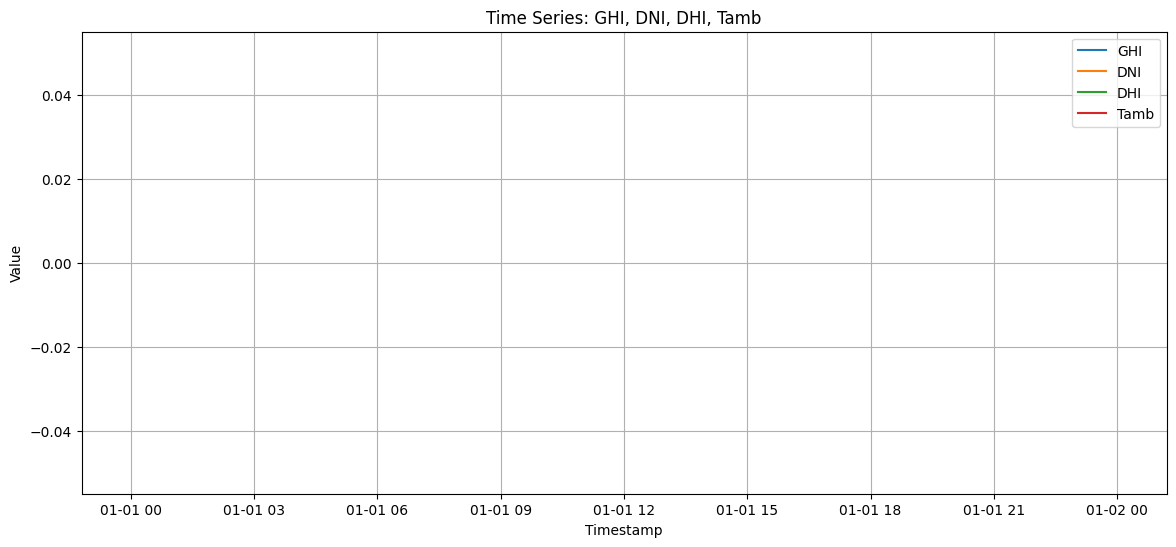

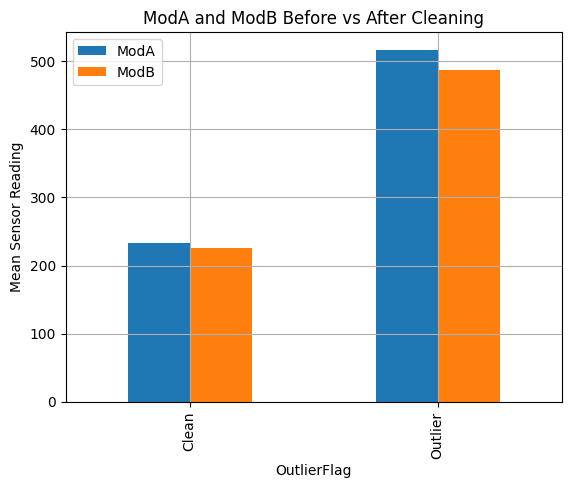

c:\Python313\Lib\site-packages\seaborn\matrix.py:202: RuntimeWarning: All-NaN slice encountered
  vmin = np.nanmin(calc_data)
c:\Python313\Lib\site-packages\seaborn\matrix.py:207: RuntimeWarning: All-NaN slice encountered
  vmax = np.nanmax(calc_data)


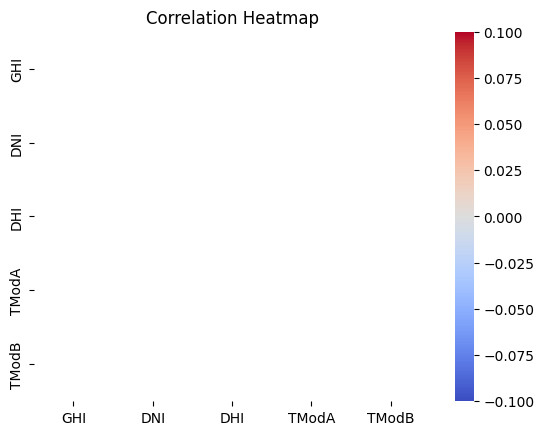

In [121]:
missing = df.isna().sum()
missing_percent = (missing / len(df)) * 100
missing_df = pd.DataFrame({'MissingValues': missing, 'Percent': missing_percent})
missing_df[missing_df['Percent'] > 5]

# Focused columns
columns_to_check = ['GHI', 'DNI', 'DHI', 'ModA', 'ModB', 'WS', 'WSgust']

# Z-score computation
z_scores = df[columns_to_check].apply(zscore)

outliers = (np.abs(z_scores) > 3)


# Flag rows with outliers
df['OutlierFlag'] = outliers.any(axis=1)

# Impute missing values with median
for col in columns_to_check:
    df[col] = df[col].fillna(df[col].median())

    # Drop remaining rows with NA (if any)
df_cleaned = df.dropna()
df_cleaned.to_csv("data/benin_clean.csv", index=False)

# Convert timestamp if needed
df_cleaned['Timestamp'] = pd.to_datetime(df_cleaned['Timestamp'])

# Plot trends
plt.figure(figsize=(14, 6))

for col in ['GHI', 'DNI', 'DHI', 'Tamb']:
    plt.plot(df_cleaned['Timestamp'], df_cleaned[col], label=col)
plt.legend()
plt.title('Time Series: GHI, DNI, DHI, Tamb')
plt.xlabel('Timestamp')
plt.ylabel('Value')
plt.grid(True)
plt.show()

# Average ModA and ModB before vs. after cleaning
comparison = df.groupby(df['OutlierFlag'])[['ModA', 'ModB']].mean()

comparison.plot(kind='bar')
plt.title("ModA and ModB Before vs After Cleaning")

plt.xticks([0, 1], ['Clean', 'Outlier'])
plt.ylabel('Mean Sensor Reading')
plt.grid(True)
plt.show()

# Correlation heatmap
corr = df_cleaned[['GHI', 'DNI', 'DHI', 'TModA', 'TModB']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

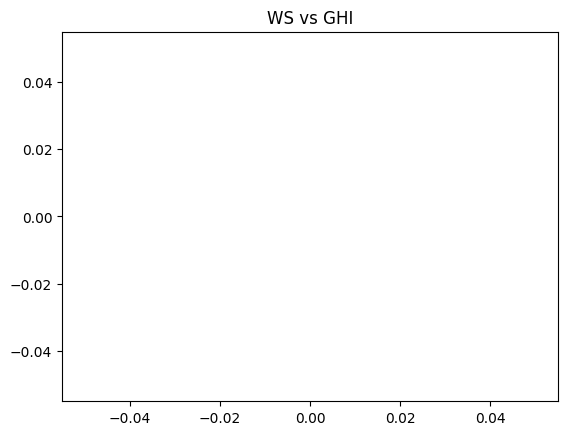

In [122]:
# Scatter plots
sns.scatterplot(x='WS', y='GHI', data=df_cleaned)
plt.title("WS vs GHI")
plt.show()

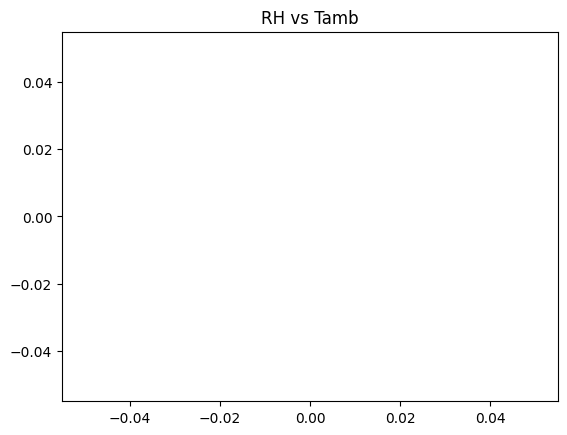

In [123]:
sns.scatterplot(x='RH', y='Tamb', data=df_cleaned)
plt.title("RH vs Tamb")
plt.show()

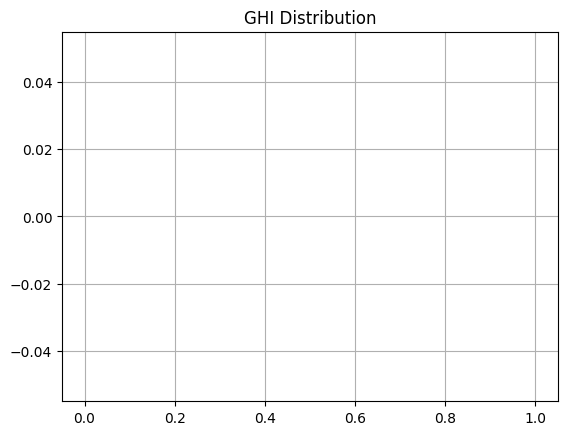

In [124]:
# Histogram of GHI
df_cleaned['GHI'].hist(bins=50)
plt.title("GHI Distribution")
plt.show()

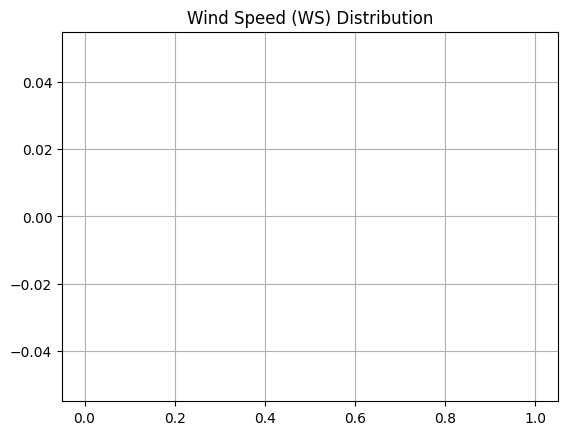

In [125]:
# Histogram of WS
df_cleaned['WS'].hist(bins=50)
plt.title("Wind Speed (WS) Distribution")
plt.show()

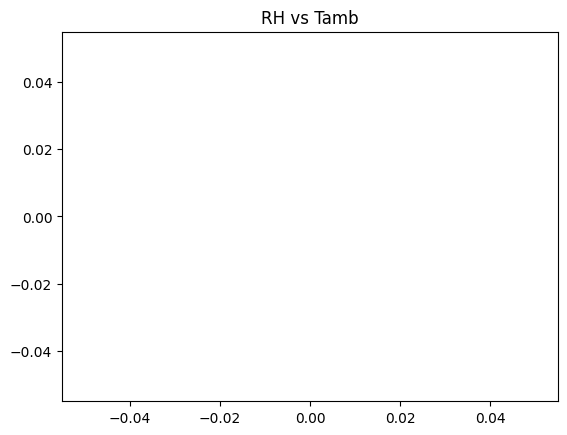

In [126]:
# Influence of RH on Tamb and GHI
sns.scatterplot(x='RH', y='Tamb', data=df_cleaned)
plt.title("RH vs Tamb")
plt.show()

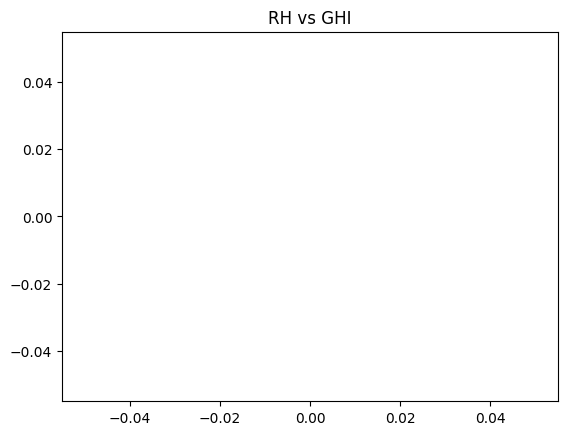

In [127]:
sns.scatterplot(x='RH', y='GHI', data=df_cleaned)
plt.title("RH vs GHI")
plt.show()

In [128]:
fig = px.scatter(df_cleaned, x='GHI', y='Tamb',
                 size='RH', color='BP', hover_data=['Timestamp'],
                 title="Bubble Chart: GHI vs Tamb (size=RH, color=BP)")
fig.show()

ValueError: Mime type rendering requires nbformat>=4.2.0 but it is not installed